In [ ]:
"""
Cross-domain evaluation using a Multi-Decoder VAE with species-conditioned prior.

Domains:
- Training / alignment: DRIAMS_A, DRIAMS_D
- Evaluation:
    - In-domain: DRIAMS_A
    - Seen domain: DRIAMS_D
    - OOD domains: DRIAMS_B, DRIAMS_C, MARISMA

The VAE is trained on A and D (train + val splits only).

A Random Forest classifier is trained on DRIAMS_A and evaluated across domains.

Comparison is performed between:
- Original space (X)
- Latent space (z)

Objective:
Assess whether the learned latent representation reduces domain shift
and improves generalization, including to fully unseen domains.
"""

## Path configuration

In [1]:
from pathlib import Path
import os

PROJECT_NAME = "MALDIAlign"

cwd = Path().resolve()

# Walk upwards until we find the project folder
target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

# If the project folder is found and we are not already there, then change cwd
if target is not None and target != cwd:
    os.chdir(target)

print("Working directory:", os.getcwd())

Working directory: /export/usuarios01/agnavarr/MALDIAlign


## Imports

In [ ]:
import pickle
import numpy as np
import pandas as pd

# utils
from src.config.loader import *
from src.data.datasets import *
from src.data.preprocessing import *
from src.evaluation.metrics import *
from src.visualization.viz import *

# models
from sklearn.ensemble import RandomForestClassifier

## Data loading

In [3]:
############################################################
# DATA LOADING
############################################################
cfg = load_config()

driams_pkl = cfg["data"]["DRIAMS_REDUCED_PKL"]
marisma_pkl = cfg["data"]["MARISMa_REDUCED_PKL"]

driams = load_pkl(driams_pkl)
marisma = load_pkl(marisma_pkl)

# -------------------------
# DRIAMS
# -------------------------
data, label, raw_meta = driams["data"], driams["label"], driams["meta"]
meta = pd.DataFrame.from_records(list(raw_meta))

# Normalize per spectrum
X_min = data.min(axis=1, keepdims=True)
X_max = data.max(axis=1, keepdims=True)
data_norm = (data - X_min) / (X_max - X_min + 1e-8)

# -------------------------
# MARISMA (OOD)
# -------------------------
data_m, label_m, raw_meta_m = marisma["data"], marisma["label"], marisma["meta"]
meta_m = pd.DataFrame.from_records(list(raw_meta_m)).copy()

meta_m.insert(0, "hospital", "MARISMA")

X_min_m = data_m.min(axis=1, keepdims=True)
X_max_m = data_m.max(axis=1, keepdims=True)
data_norm_m = (data_m - X_min_m) / (X_max_m - X_min_m + 1e-8)

# -------------------------
# FILTER PER DOMAIN
# -------------------------
filtered = {}
for hosp in meta["hospital"].unique():
    idx = np.where(meta["hospital"].values == hosp)[0]
    filtered[hosp] = {
        "data": data_norm[idx],
        "label": label[idx],
        "meta": meta.iloc[idx].reset_index(drop=True)
    }

# Assign domains
dataA, labelA, metaA = filtered["DRIAMS_A"]["data"], filtered["DRIAMS_A"]["label"], filtered["DRIAMS_A"]["meta"]
dataB, labelB, metaB = filtered["DRIAMS_B"]["data"], filtered["DRIAMS_B"]["label"], filtered["DRIAMS_B"]["meta"]
dataC, labelC, metaC = filtered["DRIAMS_C"]["data"], filtered["DRIAMS_C"]["label"], filtered["DRIAMS_C"]["meta"]
dataD, labelD, metaD = filtered["DRIAMS_D"]["data"], filtered["DRIAMS_D"]["label"], filtered["DRIAMS_D"]["meta"]

# -------------------------
# REBUILD GLOBAL DATASET (A + D)  ⭐ CLAVE
# -------------------------
selected_domains = ["DRIAMS_A", "DRIAMS_D"]

data_list, label_list, meta_list = [], [], []

for hosp in selected_domains:
    idx = np.where(meta["hospital"].values == hosp)[0]
    data_list.append(data_norm[idx])
    label_list.append(label[idx])
    meta_list.append(meta.iloc[idx])

data_final = np.vstack(data_list)
label_final = np.concatenate(label_list)
meta_final = pd.concat(meta_list, ignore_index=True).reset_index(drop=True)

# -------------------------
# LOAD SPLITS
# -------------------------
experiment_dir = Path("/export/usuarios01/agnavarr/MALDIAlign/experiments/results/vae_multidecoder_prior/20260324_172208")
splits_path = experiment_dir / "data_splits.pkl"

with open(splits_path, "rb") as f:
    splits = pickle.load(f)

# A (source)
train_idx_A = splits["splits_per_domain"]["DRIAMS_A"]["train_idx"]
test_idx_A  = splits["splits_per_domain"]["DRIAMS_A"]["test_idx"]

# D (seen)
test_idx_D  = splits["splits_per_domain"]["DRIAMS_D"]["test_idx"]

# -------------------------
# BUILD FINAL SETS 
# -------------------------

# Train (A)
X_train = data_final[train_idx_A]
y_train = label_final[train_idx_A]

# Test A
X_A_test = data_final[test_idx_A]
y_A_test = label_final[test_idx_A]

# Test D
X_D_test = data_final[test_idx_D]
y_D_test = label_final[test_idx_D]

# OOD
X_B_test, y_B_test = dataB, labelB
X_C_test, y_C_test = dataC, labelC
X_M_test, y_M_test = data_norm_m, label_m

# -------------------------
# DEBUG
# -------------------------
print(f"Train A: {X_train.shape}")
print(f"Test A: {X_A_test.shape}")
print(f"Test D (seen): {X_D_test.shape}")
print(f"Test B (OOD): {X_B_test.shape}")
print(f"Test C (OOD): {X_C_test.shape}")
print(f"Test MARISMA (OOD): {X_M_test.shape}")

Train A: (19467, 6000)
Test A: (5562, 6000)
Test D (seen): (1462, 6000)
Test B (OOD): (1986, 6000)
Test C (OOD): (2677, 6000)
Test MARISMA (OOD): (76172, 6000)


## Original space (train on DRIAMS-A (all years), test on B-C-D, MARISMA (all years))

### Train

In [4]:
rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)
rf_final.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### Test


===== Metrics =====
Domain: DRIAMS-A (in-domain)
Balanced Accuracy: 0.9982
F1 Macro: 0.9986
Recall Macro: 0.9982
Specificity Macro: 0.9997



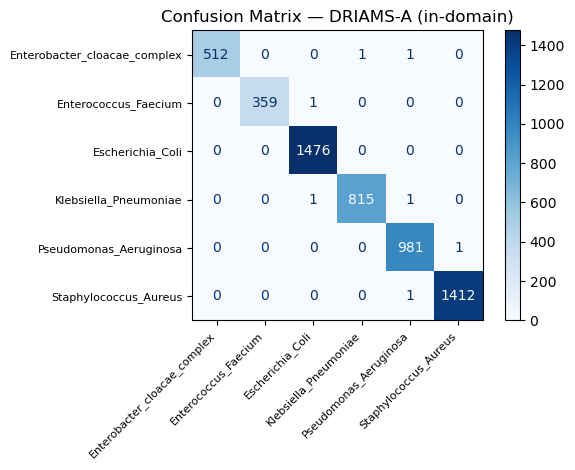


===== Metrics =====
Domain: DRIAMS-B (OOD)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



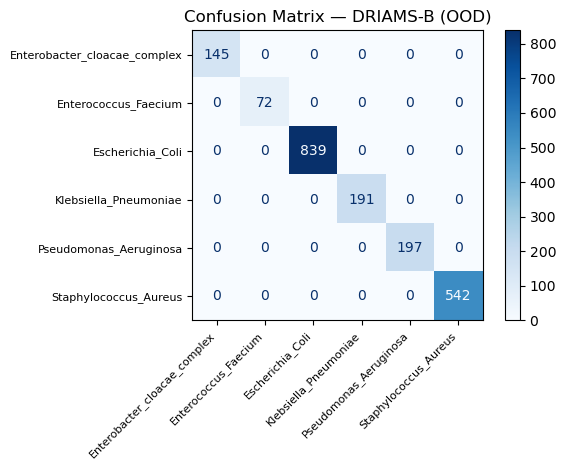


===== Metrics =====
Domain: DRIAMS-C (OOD)
Balanced Accuracy: 0.9964
F1 Macro: 0.9971
Recall Macro: 0.9964
Specificity Macro: 0.9995



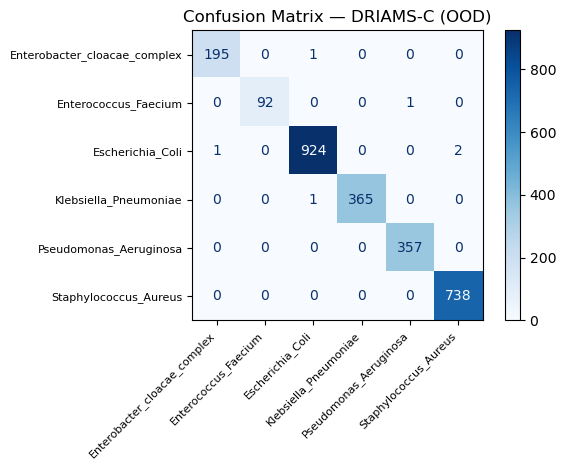


===== Metrics =====
Domain: DRIAMS-D (seen)
Balanced Accuracy: 0.9125
F1 Macro: 0.8973
Recall Macro: 0.9125
Specificity Macro: 0.9784



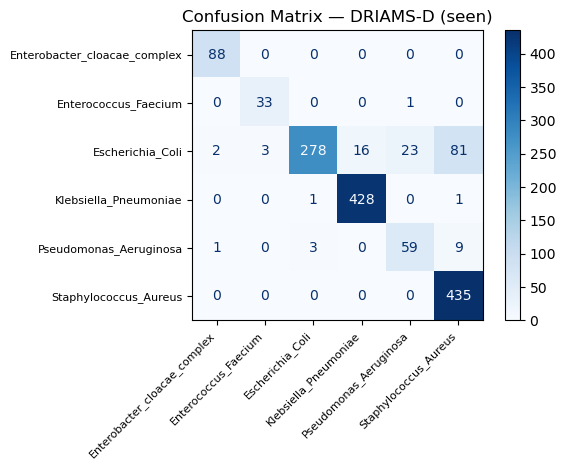


===== Metrics =====
Domain: MARISMA (OOD)
Balanced Accuracy: 0.9896
F1 Macro: 0.9927
Recall Macro: 0.9896
Specificity Macro: 0.9994



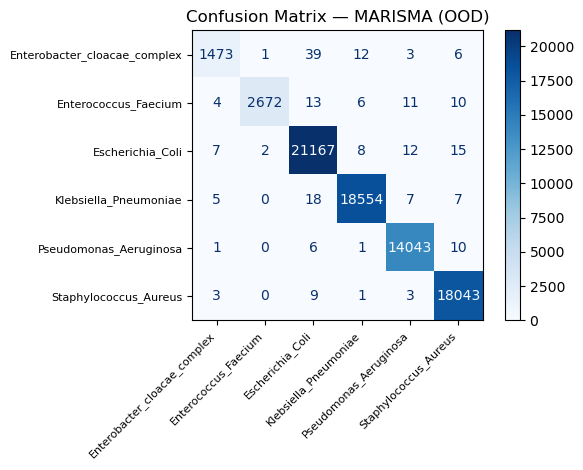

In [5]:
metricsA = metrics_report(X_A_test, y_A_test, rf_final, "DRIAMS-A (in-domain)")
metricsD = metrics_report(X_D_test, y_D_test, rf_final, "DRIAMS-D (seen)")
metricsB = metrics_report(X_B_test, y_B_test, rf_final, "DRIAMS-B (OOD)")
metricsC = metrics_report(X_C_test, y_C_test, rf_final, "DRIAMS-C (OOD)")
metrics_marisma = metrics_report(X_M_test, y_M_test, rf_final, "MARISMA (OOD)")

print_metrics(metricsA)
print_metrics(metricsB)
print_metrics(metricsC)
print_metrics(metricsD)
print_metrics(metrics_marisma)

## After domain alignment

#### Utils

In [6]:
import torch
from models.deep.MultiVAEPrior import MultiVAE_Bernoulli_SpeciesPrior_Extended
from sklearn.ensemble import RandomForestClassifier

In [7]:
def load_model(model, path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model

def encode_latent(model, X, device, batch_size=256):
    model.eval()
    Z = []

    X_tensor = torch.tensor(X, dtype=torch.float32)

    loader = torch.utils.data.DataLoader(
        X_tensor,
        batch_size=batch_size,
        shuffle=False
    )

    with torch.no_grad():
        for x in loader:
            x = x.to(device)
            mu, _ = model.encoder(x)
            Z.append(mu.cpu().numpy())

    return np.vstack(Z)

#### Load and train

In [8]:
data_all = np.vstack([
    dataA,
    dataD
])

meta_all = pd.concat([
    metaA,
    metaD
], ignore_index=True)

label_all = np.concatenate([
    labelA,
    labelD
])

In [9]:
vae_path = "/export/usuarios01/agnavarr/MALDIAlign/experiments/results/vae_multidecoder_prior/20260324_172208/model.pth"

backbone = MultiVAE_Bernoulli_SpeciesPrior_Extended(
    input_dim=data_all.shape[1],
    latent_dim=64,
    num_domains=2,
    n_species=len(np.unique(label_all))
)

vae = load_model(backbone, vae_path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
Z_all = encode_latent(
    model=vae,
    X=data_all,
    device=device
)

# Train (A)
Z_train = Z_all[train_idx_A]
y_train_z = label_all[train_idx_A]

# Test A
Z_A_test = Z_all[test_idx_A]
y_A_test = label_all[test_idx_A]

# Test D
Z_D_test = Z_all[test_idx_D]
y_D_test = label_all[test_idx_D]

# OOD
Z_B = encode_latent(vae, dataB, device)
Z_C = encode_latent(vae, dataC, device)
Z_M = encode_latent(vae, data_norm_m, device)

y_B = labelB
y_C = labelC
y_M = label_m

In [11]:
rf_latent = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

rf_latent.fit(Z_train, y_train_z)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

#### Test


===== Metrics =====
Domain: DRIAMS-A (in-domain)
Balanced Accuracy: 0.9976
F1 Macro: 0.9980
Recall Macro: 0.9976
Specificity Macro: 0.9996



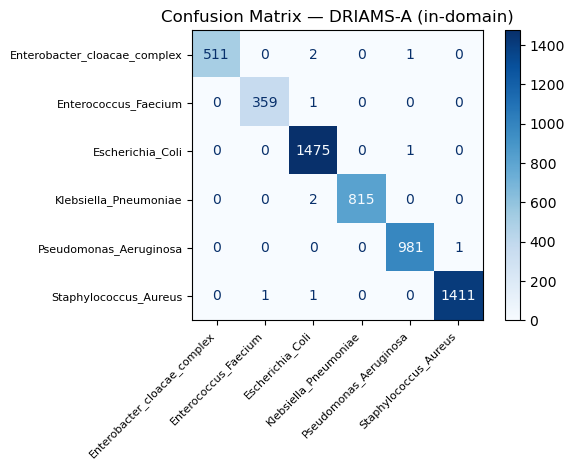


===== Metrics =====
Domain: DRIAMS-D (seen)
Balanced Accuracy: 0.9645
F1 Macro: 0.9726
Recall Macro: 0.9645
Specificity Macro: 0.9962



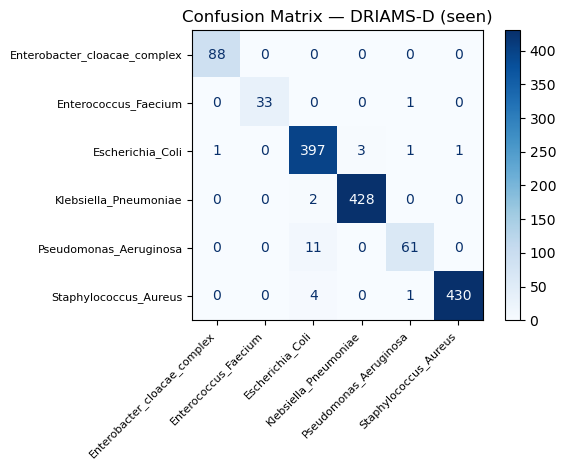


===== Metrics =====
Domain: DRIAMS-B (OOD)
Balanced Accuracy: 0.9951
F1 Macro: 0.9972
Recall Macro: 0.9951
Specificity Macro: 0.9996



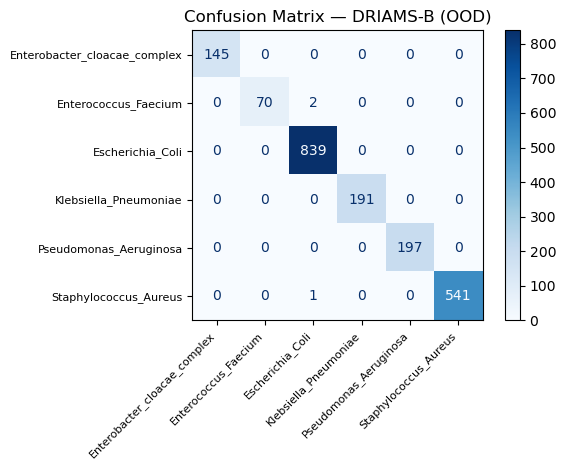


===== Metrics =====
Domain: DRIAMS-C (OOD)
Balanced Accuracy: 0.9949
F1 Macro: 0.9967
Recall Macro: 0.9949
Specificity Macro: 0.9996



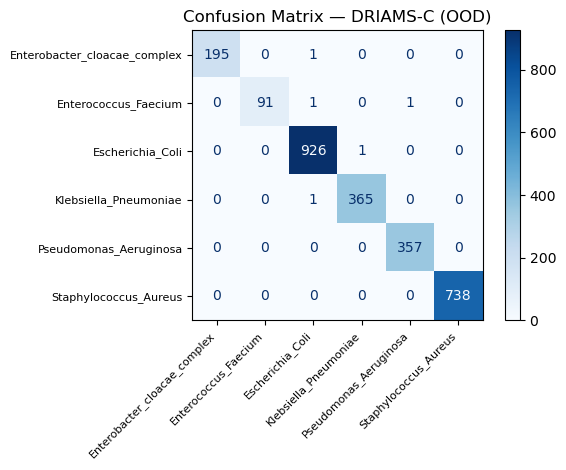


===== Metrics =====
Domain: MARISMA (OOD)
Balanced Accuracy: 0.9857
F1 Macro: 0.9902
Recall Macro: 0.9857
Specificity Macro: 0.9986



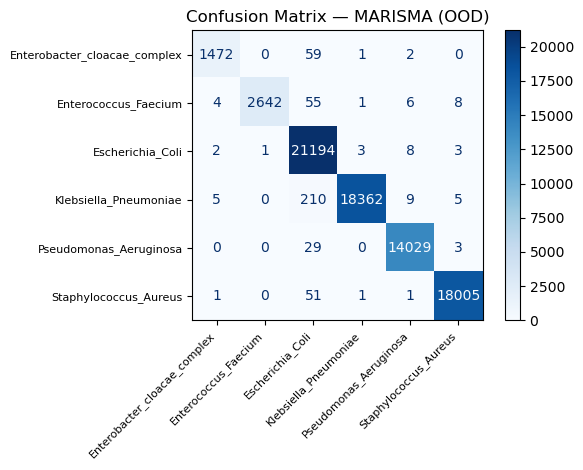

In [12]:
metrics_A = metrics_report(Z_A_test, y_A_test, rf_latent, "DRIAMS-A (in-domain)")
metrics_D = metrics_report(Z_D_test, y_D_test, rf_latent, "DRIAMS-D (seen)")
metrics_B = metrics_report(Z_B, y_B, rf_latent, "DRIAMS-B (OOD)")
metrics_C = metrics_report(Z_C, y_C, rf_latent, "DRIAMS-C (OOD)")
metrics_M = metrics_report(Z_M, y_M, rf_latent, "MARISMA (OOD)")

print_metrics(metrics_A)
print_metrics(metrics_D)
print_metrics(metrics_B)
print_metrics(metrics_C)
print_metrics(metrics_M)